In [1]:
%cd /content/STTran
!git clone https://github.com/TommasoAiello08/STTran

[Errno 2] No such file or directory: '/content/STTran'
/content
Cloning into 'STTran'...
remote: Enumerating objects: 905, done.
remote: Counting objects: 100% (905/905), done.
remote: Compressing objects: 100% (626/626), done.
remote: Total 905 (delta 349), reused 801 (delta 245), pack-reused 0 (from 0)
Receiving objects: 100% (905/905), 11.57 MiB | 16.37 MiB/s, done.
Resolving deltas: 100% (349/349), done.


In [2]:
# Mount Google Drive (where the VIDVRD zip + outputs live)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# 1) Clone repo (edit URL if you use a fork)
%cd /content
!rm -rf STTran
!git clone https://github.com/TommasoAiello08/STTran.git STTran
%cd /content/STTran




/content
Cloning into 'STTran'...
remote: Enumerating objects: 905, done.
remote: Counting objects: 100% (905/905), done.
remote: Compressing objects: 100% (626/626), done.
remote: Total 905 (delta 349), reused 801 (delta 245), pack-reused 0 (from 0)
Receiving objects: 100% (905/905), 11.57 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (349/349), done.
/content/STTran


In [3]:
%%bash
set -euo pipefail
set -x

cd /content/STTran
# Idempotent: reruns should be fast (uses .colab_setup_stamp.json)
python -u setup_colab.py --colab


[colab] Skipping legacy native extension build (use --compile-native or STTRAN_COMPILE_NATIVE=1 to force).
STTran Colab setup  repo_root=/content/STTran
+ /usr/bin/python3 -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
[colab] keeping existing torch 2.10.0+cu128 (cuda=True)
+ /usr/bin/python3 -m pip install numpy scipy imageio pillow tqdm six cython ninja matplotlib networkx gdown pyyaml opencv-python pandas dill easydict h5py
[download] http://nlp.stanford.edu/data/glove.6B.zip -> /content/STTran/data/glove.6B.zip
+ /usr/bin/python3 /content/STTran/scripts/download_sttran_ag_weights.py --out_dir /content/STTran/.sttran_weight_cache --link_into_repo
[download] /content/STTran/.sttran_weight_cache/faster_rcnn_ag.pth
[download] /content/STTran/.sttran_weight_cache/object_bbox_and_relations

+ cd /content/STTran
+ python -u setup_colab.py --colab
Downloading...
From (original): https://drive.google.com/uc?id=1-u930Pk0JYz3ivS6V_HNTM1D5AxmN5Bs
From (redirected): https://drive.google.com/uc?id=1-u930Pk0JYz3ivS6V_HNTM1D5AxmN5Bs&confirm=t&uuid=57c82468-3b96-4123-ba16-a374d5ff6cb6
To: /content/STTran/.sttran_weight_cache/faster_rcnn_ag.pth
100%|██████████| 380M/380M [00:07<00:00, 49.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=19BkAwjCw5ByyGyZjFo174Oc3Ud56fkaT
From (redirected): https://drive.google.com/uc?id=19BkAwjCw5ByyGyZjFo174Oc3Ud56fkaT&confirm=t&uuid=66c94023-b590-4c53-bc12-2172b6330f73
To: /content/STTran/.sttran_weight_cache/object_bbox_and_relationship_filtersmall.pkl
100%|██████████| 136M/136M [00:02<00:00, 53.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Sk5qFLWTZmwr63fHpy_C7oIxZSQU16vU
From (redirected): https://drive.google.com/uc?id=1Sk5qFLWTZmwr63fHpy_C7oIxZSQU16vU&confirm=t&uuid=d526b04f-9844-434e-a0e0-94f0792c12

In [4]:
# Optional: if you keep big weights on Drive instead of inside the repo, set these.
# Otherwise, skip this cell.

import os

os.environ["FASTER_RCNN_AG_PTH"] = "/content/drive/MyDrive/weights/faster_rcnn_ag.pth"
os.environ["STTRAN_CKPT"] = "/content/drive/MyDrive/weights/sttran_predcls.tar"


In [5]:

import os

# Point detector weights to the in-repo file (downloaded by setup_colab.py)
os.environ["FASTER_RCNN_AG_PTH"] = "/content/STTran/fasterRCNN/models/faster_rcnn_ag.pth"

# (optional) ensure STTran ckpt override isn't pointing to Drive
os.environ["STTRAN_CKPT"] = "/content/STTran/ckpts/sttran_predcls.tar"

print("FASTER_RCNN_AG_PTH =", os.environ["FASTER_RCNN_AG_PTH"])
print("STTRAN_CKPT       =", os.environ["STTRAN_CKPT"])

FASTER_RCNN_AG_PTH = /content/STTran/fasterRCNN/models/faster_rcnn_ag.pth
STTRAN_CKPT       = /content/STTran/ckpts/sttran_predcls.tar


In [6]:
# Build an s8 dataset FROM THE FULL (non-s8) VIDVRD zip.
# This cell *reduces frames* (keeps 1 frame every STRIDE) and rewrites JSON accordingly.
# If you already have `vidvrd-dataset_480_s8.zip`, do NOT run this cell; use the plain unzip/import cell instead.

import os, re, json, math, shutil
from pathlib import Path
import zipfile

ZIP_PATH = Path("/content/drive/MyDrive/vidvrd-dataset_480.zip")  # full dataset zip (NOT *_s8.zip)
OUT_ROOT = Path("/content/vidvrd-dataset_480_s8")
STRIDE = 8

assert ZIP_PATH.is_file(), f"ZIP not found: {ZIP_PATH}"
assert "_s8" not in ZIP_PATH.name, (
    f"This reducer expects the FULL zip, but got {ZIP_PATH.name}. "
    "Use the s8 unzip/import cell for *_s8.zip instead."
)

# Fresh output (delete if you want to rebuild from scratch)
if OUT_ROOT.exists():
    print("[info] OUT_ROOT exists; will resume (per-video).")
else:
    OUT_ROOT.mkdir(parents=True, exist_ok=True)

for split in ["train", "test"]:
    (OUT_ROOT / f"{split}_480").mkdir(parents=True, exist_ok=True)
    (OUT_ROOT / f"{split}_frames_480").mkdir(parents=True, exist_ok=True)

img_re  = re.compile(r"(?:^|/)(train_frames_480|test_frames_480)/([^/]+)/(\d+)\.(png|jpg|jpeg)$", re.I)
json_re = re.compile(r"(?:^|/)(train_480|test_480)/([^/]+)\.json$", re.I)

def rewrite_json_stride(d: dict, stride: int) -> dict:
    traj = d.get("trajectories", [])
    fc = int(d.get("frame_count", len(traj)))
    fc = min(fc, len(traj))
    keep_idx = list(range(0, fc, stride))
    traj_new = [traj[i] for i in keep_idx if i < len(traj)]

    def b_new(b): return int(b // stride)
    def e_new(e): return int((e + stride - 1) // stride)  # ceil

    rel_new = []
    for r in d.get("relation_instances", []):
        b = int(r["begin_fid"]); e = int(r["end_fid"])
        bn = max(0, min(b_new(b), len(traj_new)))
        en = max(0, min(e_new(e), len(traj_new)))
        if en <= bn:
            continue
        r2 = dict(r)
        r2["begin_fid"] = bn
        r2["end_fid"] = en
        rel_new.append(r2)

    d2 = dict(d)
    d2["frame_count"] = len(traj_new)
    d2["trajectories"] = traj_new
    d2["relation_instances"] = rel_new
    d2["frame_stride"] = stride
    return d2

print("Indexing zip members...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    names = zf.namelist()

frames = {"train": {}, "test": {}}
json_members = {"train": {}, "test": {}}

for n in names:
    m = json_re.search(n)
    if m:
        split = "train" if m.group(1).lower().startswith("train") else "test"
        vid = m.group(2)
        json_members[split][vid] = n
        continue
    m = img_re.search(n)
    if m:
        split = "train" if m.group(1).lower().startswith("train") else "test"
        vid = m.group(2)
        idx = int(m.group(3))
        frames[split].setdefault(vid, []).append((idx, n))

for split in ["train", "test"]:
    for vid in frames[split]:
        frames[split][vid].sort(key=lambda x: x[0])

print("Found JSONs:", {k: len(v) for k, v in json_members.items()})
print("Found frame dirs:", {k: len(v) for k, v in frames.items()})

def extract_video(zf: zipfile.ZipFile, split: str, vid: str):
    out_json = OUT_ROOT / f"{split}_480" / f"{vid}.json"
    out_frames_dir = OUT_ROOT / f"{split}_frames_480" / vid
    out_frames_dir.mkdir(parents=True, exist_ok=True)

    # resumable: if json exists and at least 1 frame exists, skip
    if out_json.exists() and any(out_frames_dir.iterdir()):
        return "skip"

    jm = json_members[split].get(vid)
    if jm is None:
        return "no_json"

    d = json.loads(zf.read(jm).decode("utf-8"))
    d2 = rewrite_json_stride(d, STRIDE)
    out_json.write_text(json.dumps(d2, indent=2) + "\n", encoding="utf-8")

    flist = frames[split].get(vid, [])
    keep = flist[::STRIDE]
    kept = 0
    for new_i, (_old_i, member) in enumerate(keep):
        ext = Path(member).suffix.lower()
        out_path = out_frames_dir / f"{new_i:06d}{ext}"
        if out_path.exists():
            continue
        out_path.write_bytes(zf.read(member))
        kept += 1
    return f"ok kept={kept}"

for split in ["train", "test"]:
    vids = sorted(json_members[split].keys())
    print(f"\nExtracting split={split} videos={len(vids)} stride={STRIDE}")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        for i, vid in enumerate(vids, 1):
            st = extract_video(zf, split, vid)
            if i % 50 == 0:
                print(f"  [{split}] {i}/{len(vids)} {vid}: {st}")

print("\nDONE. Reduced dataset at:", OUT_ROOT)
os.system(f"du -sh {OUT_ROOT} || true")
print("Use DATASET_ROOT =", str(OUT_ROOT))

Indexing zip members...
Found JSONs: {'train': 572, 'test': 148}
Found frame dirs: {'train': 572, 'test': 148}

Extracting split=train videos=572 stride=8
  [train] 50/572 ILSVRC2015_train_00040029: ok kept=8
  [train] 100/572 ILSVRC2015_train_00068003: ok kept=4
  [train] 150/572 ILSVRC2015_train_00109003: ok kept=66
  [train] 200/572 ILSVRC2015_train_00159008: ok kept=15
  [train] 250/572 ILSVRC2015_train_00232001: ok kept=83
  [train] 300/572 ILSVRC2015_train_00272005: ok kept=6
  [train] 350/572 ILSVRC2015_train_00404004: ok kept=94
  [train] 400/572 ILSVRC2015_train_00623001: ok kept=55
  [train] 450/572 ILSVRC2015_train_00880000: ok kept=64
  [train] 500/572 ILSVRC2015_train_01108003: ok kept=45
  [train] 550/572 ILSVRC2015_val_00046003: ok kept=68

Extracting split=test videos=148 stride=8
  [test] 50/148 ILSVRC2015_train_00194007: ok kept=23
  [test] 100/148 ILSVRC2015_train_00663000: ok kept=72

DONE. Reduced dataset at: /content/vidvrd-dataset_480_s8
Use DATASET_ROOT = /conte

In [7]:
%%bash
set -euo pipefail
set -x

SRC="/content/vidvrd-dataset_480_s8"
OUT="/content/drive/MyDrive/vidvrd-dataset_480_s8.zip"

test -d "$SRC/train_480"
test -d "$SRC/train_frames_480"

# Remove any previous zip (optional)
rm -f "$OUT"

# Create zip (stored) with relative paths
cd "$(dirname "$SRC")"
zip -rq "$OUT" "$(basename "$SRC")"

ls -lah "$OUT"

-rw------- 1 root root 11G May  5 17:54 /content/drive/MyDrive/vidvrd-dataset_480_s8.zip


+ SRC=/content/vidvrd-dataset_480_s8
+ OUT=/content/drive/MyDrive/vidvrd-dataset_480_s8.zip
+ test -d /content/vidvrd-dataset_480_s8/train_480
+ test -d /content/vidvrd-dataset_480_s8/train_frames_480
+ rm -f /content/drive/MyDrive/vidvrd-dataset_480_s8.zip
++ dirname /content/vidvrd-dataset_480_s8
+ cd /content
++ basename /content/vidvrd-dataset_480_s8
+ zip -rq /content/drive/MyDrive/vidvrd-dataset_480_s8.zip vidvrd-dataset_480_s8
+ ls -lah /content/drive/MyDrive/vidvrd-dataset_480_s8.zip


In [ ]:
%%bash
set -euo pipefail
set -x

ZIP="/content/drive/MyDrive/vidvrd-dataset_480.zip"
OUT="/content/vidvrd-dataset_480"

rm -rf "$OUT"
mkdir -p "$OUT"

# Extract directly into OUT
unzip -q "$ZIP" -d "$OUT"

echo "[ok] extracted into $OUT"
ls -lah "$OUT" | head -n 50

# If the zip contains an extra top-level folder, flatten it
if [ -d "$OUT/VIDVRD-DATASET_480" ] && [ ! -d "$OUT/train_480" ]; then
  echo "[flatten] moving $OUT/VIDVRD-DATASET_480/* -> $OUT/"
  shopt -s dotglob
  mv "$OUT/VIDVRD-DATASET_480/"* "$OUT/"
  rmdir "$OUT/VIDVRD-DATASET_480" || true
fi

# Sanity check
ls -lah "$OUT" | head -n 50
test -d "$OUT/train_480" && test -d "$OUT/train_frames_480" && echo "[ok] train split present"
test -d "$OUT/test_480" && test -d "$OUT/test_frames_480" && echo "[ok] test split present"
du -sh "$OUT" || true

Process is interrupted.


In [ ]:
# Quick sanity check: confirm dataset exists on Drive
from pathlib import Path

DATASET_ROOT = Path("/content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480")
print("DATASET_ROOT:", DATASET_ROOT)
print("has test_frames_480:", (DATASET_ROOT / "test_frames_480").is_dir())
print("has test_480:", (DATASET_ROOT / "test_480").is_dir())
print("has train_frames_480:", (DATASET_ROOT / "train_frames_480").is_dir())
print("has train_480:", (DATASET_ROOT / "train_480").is_dir())


DATASET_ROOT: /content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480
has test_frames_480: True
has test_480: True
has train_frames_480: True
has train_480: True


In [ ]:
%%bash
set -euo pipefail
set -x

cd /content/STTran
python -u lib/vidvrd_pipeline_validate.py \
  --dataset_root "/content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480" \
  --video_id "ILSVRC2015_train_00010001" \
  --expected_hw "480,854" \
  --max_frames 32 \
  --num_predicates 0

ok: False
ERROR: detector/featurizer init failed (weights missing?). Retry with --mock_featurizer. Detail: [Errno 2] No such file or directory: '/content/drive/MyDrive/weights/faster_rcnn_ag.pth'
WARN: len(trajectories)=210 != frame_count=219 in JSON; pipeline will min-truncate to im_data length.
WARN: object_categories / predicate_names not provided; built vocab from this JSON only. For real training pass the full official lists so indices are stable.
diagnostics: {
  "video_id": "ILSVRC2015_train_00010001",
  "json_frame_count": 219,
  "json_wh": [
    854,
    480
  ],
  "num_trajectory_frames": 210,
  "num_relations": 33,
  "T_use": 32,
  "T_disk": 219,
  "frame_start": 0,
  "num_vidvrd_predicates_inferred": 14,
  "im_data_shape": [
    32,
    3,
    600,
    1068
  ],
  "im_info_first_row": [
    600.0,
    1068.0,
    1.25
  ],
  "prep_scales_first8": [
    1.25,
    1.25,
    1.25,
    1.25,
    1.25,
    1.25,
    1.25,
    1.25
  ]
}


+ cd /content/STTran
+ python -u lib/vidvrd_pipeline_validate.py --dataset_root /content/drive/MyDrive/VIDVRD/VIDVRD-DATASET_480 --video_id ILSVRC2015_train_00010001 --expected_hw 480,854 --max_frames 32 --num_predicates 0


In [ ]:
%cd /content/STTran
!python colab/vidvrd_train_colab.py \
  --out_dir "/content/drive/MyDrive/vidvrd_runs/smoke_synth" \
  --epochs 1 \
  --synthetic


/content/STTran
Base checkpoint not found: '/content/drive/MyDrive/weights/sttran_predcls.tar'


In [ ]:
!git pull https://github.com/TommasoAiello08/STTran


From https://github.com/TommasoAiello08/STTran
 * branch            HEAD       -> FETCH_HEAD
Already up to date.



===== RUNNING =====
cd /content/STTran && git pull

Already up to date.

[frame_index] kept 572/572 videos with frames -> /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/train_video_ids_with_frames.json

===== RUNNING =====

set -e
cd /content/STTran
python -u colab/vidvrd_train_colab.py   --out_dir "/content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352"   --log_csv "/content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/losses.csv"   --best_ckpt_name "best.pt"   --min_delta 0.0   --patience 2   --dataset_root "/content/vidvrd-dataset_480_s8"   --vocab_json "/content/drive/MyDrive/vidvrd_runs/vidvrd_vocab.json"   --split train   --epochs 5   --stage head   --max_videos 0   --max_frames 16   --frame_start 0   --neg_ratio 2   --seed 42   --log_every 50   --accum_steps 8   --grad_clip 5.0   --optimizer adamw   --weight_decay 0.0001   --momentum 0.9   --lr_head 0.0005   --lr_trunk 0.0   --base_ckpt "/content/STTran/ckpts/sttran_predcls.tar"   --

/content/STTran/colab/vidvrd_train_colab.py:548: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/STTran/lib/vidvrd_train_utils.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  out_ctx = torch.cuda.amp.autocast(enabled=bool(use_amp) and torch.cuda.is_available())



[vidvrd] category->AG index map: 34 entries (for STTran obj_embed)
loading word vectors from /content/STTran/data/glove.6B.200d.pt
loading word vectors from /content/STTran/data/glove.6B.200d.pt
__background__ -> __background__ 
fail on __background__
[trunk_freeze] frozen_params=4 prefixes=['glocal_transformer.local_attention.layers.0.self_attn']
device=cuda:0  stage=trunk  trainable_params=88601616  lr_head=5e-05  lr_trunk=1e-06
epoch 1/5  videos_in_epoch=572  (total_json=572)  shuffle=True
epoch 1/5  video 1/572  ILSVRC2015_train_00484001  loss=0.3005  grad_norm=0.000  dt[s]:json=0.00 io=0.36 feat=0.24 bw=0.25 step=0.00 total=0.85  cuda_max_alloc=2.33GB
[step_fail] stage=trunk epoch=1 video_idx=10/572 video_id=ILSVRC2015_train_00555000: Non-finite gradient in param=sttran.glocal_transformer.local_attention.layers.0.linear1.weight at index=(0, 0), value=nan
[rollback_lr] lr_drop_count=1 new_lrs=[1e-05, 1e-05, 2e-07, 2e-07]
[step_fail] stage=trunk epoch=1 video_idx=19/572 video_id=ILS

/content/STTran/colab/vidvrd_train_colab.py:548: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/content/STTran/lib/vidvrd_train_utils.py:164: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  out_ctx = torch.cuda.amp.autocast(enabled=bool(use_amp) and torch.cuda.is_available())



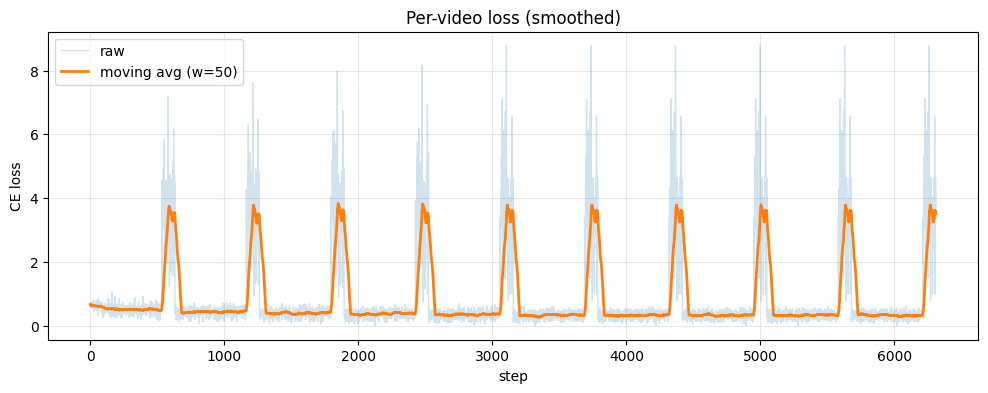

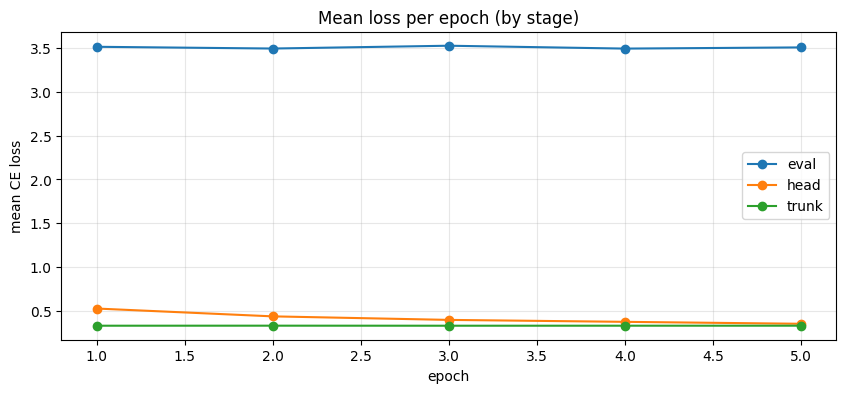

Best checkpoint: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/checkpoints/best.pt
Best meta: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/checkpoints/best_meta.json
Frame index: /content/drive/MyDrive/vidvrd_runs/s8_20x_restart1_20260505_200352/train_video_ids_with_frames.json


In [20]:
# ===================== VIDVRD TRAIN + BEST + PLOTS (ONE CELL) =====================

# --------------------- MODE ---------------------
RUN = "joint"        # "head" | "trunk" | "both" | "joint"
GIT_PULL = True

# Resume in-place inside OUT_ROOT/RUN_NAME (keeps best_meta.json + appends to losses.csv)
RESUME_RUN = True

# Fresh run should be False when resuming.
FRESH_RUN = False
RUN_NAME = "First_good_try"

# If True: build a filtered list of train videos that actually have frames (recommended)
BUILD_FRAME_INDEX = True
# ------------------------------------------------

# --------------------- PATHS ---------------------------
DATASET_ROOT = "/content/vidvrd-dataset_480_s8"
VOCAB_JSON   = "/content/drive/MyDrive/vidvrd_runs/vidvrd_vocab.json"
OUT_ROOT     = "/content/drive/MyDrive/vidvrd_runs"

# ActionGenome pretrained checkpoint (put it on Drive, then we copy it locally).
CKPT_DRIVE   = "/content/drive/MyDrive/ckpts/sttran_predcls.tar"
BASE_CKPT    = "/content/STTran/ckpts/sttran_predcls.tar"  # local copy used by trainer
# -------------------------------------------------------

# --------------------- DATA SETTINGS -------------------
SPLIT         = "train"
MAX_VIDEOS    = 0          # 0 = all (but after filtering by frames index)
# Frame windowing: warm up with fewer frames, then increase to get more supervision.
MAX_FRAMES              = 24   # after warmup
MAX_FRAMES_WARMUP_EPOCHS = 2
MAX_FRAMES_WARMUP_VALUE  = 16

FRAME_START   = 0
NEG_RATIO     = 2
SHUFFLE       = True
SEED          = 42
LOG_EVERY     = 50
VIDEO_IDS     = ""         # optional override: "id1,id2,..."
PROFILE_EVERY = 50         # if supported by your script

# Validation (new in trainer)
EVAL_SPLIT       = "test"  # "" disables
EVAL_MAX_VIDEOS  = 100     # 0 = all (slower)
# -------------------------------------------------------

# --------------------- CHECKPOINT / EARLY STOP --------------------
BEST_CKPT_NAME = "best.pt"
MIN_DELTA      = 0.0
PATIENCE_HEAD  = 5
PATIENCE_TRUNK = 5
SAVE_BEST_ONLY = False
# -------------------------------------------------------

# --------------------- TRUNK CONTROL -------------------
# IMPORTANT: if you want to train the transformer, this must be empty.
# Any prefix here will be kept frozen even in trunk/joint stages.
FREEZE_TRUNK_PREFIX = ""  # e.g. "glocal_transformer.local_attention.layers.0.self_attn"
# -------------------------------------------------------

# --------------------- STAGE 1 (HEAD) ------------------
EPOCHS_HEAD      = 5
OPT_HEAD         = "adamw"
LR_HEAD_1        = 5e-4
WEIGHT_DECAY_1   = 1e-4
MOMENTUM_1       = 0.9
AMP_HEAD         = True
ACCUM_STEPS_HEAD = 8
GRAD_CLIP_HEAD   = 5.0
# -------------------------------------------------------

# --------------------- STAGE 2 (TRUNK) -----------------
EPOCHS_TRUNK      = 5
OPT_TRUNK         = "adamw"
LR_HEAD_2         = 5e-5
LR_TRUNK_2        = 1e-6  # keep very low; trunk is numerically fragile on VIDVRD
WEIGHT_DECAY_2    = 1e-4
MOMENTUM_2        = 0.9
AMP_TRUNK         = False
ACCUM_STEPS_TRUNK = 8
GRAD_CLIP_TRUNK   = 0.5
# -------------------------------------------------------

# --------------------- JOINT (HEAD+TRUNK TOGETHER) ------
# Uses colab/vidvrd_train_colab.py --stage joint (resume from latest checkpoint in OUT_DIR).
EPOCHS_JOINT            = 20
JOINT_WARMUP_EPOCHS     = 0   # 0 = trunk trains from step 1
OPT_JOINT               = "adamw"
LR_HEAD_J               = 1e-4
LR_TRUNK_J              = 2e-7
WEIGHT_DECAY_J          = 1e-4
MOMENTUM_J              = 0.9
AMP_JOINT               = False
ACCUM_STEPS_JOINT       = 8
GRAD_CLIP_JOINT         = 0.5
# -------------------------------------------------------

import os, subprocess, sys, json
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


def sh(cmd: str):
    print("\n===== RUNNING =====\n" + cmd + "\n===================\n")
    p = subprocess.run(["bash", "-lc", cmd], text=True, capture_output=True)
    if p.stdout:
        print(p.stdout)
    if p.stderr:
        print(p.stderr, file=sys.stderr)
    if p.returncode != 0:
        raise RuntimeError(f"command failed with exit code {p.returncode}")


if GIT_PULL:
    sh("cd /content/STTran && git pull")

# Ensure AG checkpoint is available locally (copy from Drive once).
if not os.path.exists(BASE_CKPT):
    if not os.path.exists(CKPT_DRIVE):
        raise RuntimeError(f"Missing CKPT_DRIVE: {CKPT_DRIVE}. Upload sttran_predcls.tar to Drive first.")
    sh(f"mkdir -p /content/STTran/ckpts && cp -f \"{CKPT_DRIVE}\" \"{BASE_CKPT}\" && ls -lah \"{BASE_CKPT}\"")

# Fix weight overrides (avoid stale Drive paths)
os.environ["FASTER_RCNN_AG_PTH"] = "/content/STTran/fasterRCNN/models/faster_rcnn_ag.pth"
os.environ["STTRAN_CKPT"] = BASE_CKPT

for p, label in [
    (DATASET_ROOT, "DATASET_ROOT"),
    (VOCAB_JSON, "VOCAB_JSON"),
    (BASE_CKPT, "BASE_CKPT"),
    (os.environ["FASTER_RCNN_AG_PTH"], "FASTER_RCNN_AG_PTH"),
]:
    if not os.path.exists(p):
        print(f"MISSING {label}: {p}", file=sys.stderr)
        raise SystemExit(1)

# --------------------- PREFLIGHT (fast, fail-early) ---------------------
from pathlib import Path
import json as _json

root = Path(DATASET_ROOT)
train_json_dir = root / "train_480"
train_frames_dir = root / "train_frames_480"
test_json_dir = root / "test_480"
test_frames_dir = root / "test_frames_480"

for d in [train_json_dir, train_frames_dir, test_json_dir, test_frames_dir]:
    if not d.is_dir():
        raise RuntimeError(f"[preflight] missing dataset subdir: {d}")

train_jsons = sorted(train_json_dir.glob("*.json"))
if not train_jsons:
    raise RuntimeError(f"[preflight] no train jsons under: {train_json_dir}")

# Quick sample alignment check (no detector run): ensure frame dir exists + has images.
_sample = [p.stem for p in train_jsons[:5]]
for vid in _sample:
    fd = train_frames_dir / vid
    if not fd.is_dir():
        raise RuntimeError(f"[preflight] missing frames dir for {vid}: {fd}")
    imgs = [n for n in os.listdir(fd) if n.lower().endswith((".jpg", ".jpeg", ".png"))]
    if len(imgs) == 0:
        raise RuntimeError(f"[preflight] empty frames dir for {vid}: {fd}")

# Vocab must be parseable and contain expected keys.
_vocab = _json.loads(Path(VOCAB_JSON).read_text(encoding="utf-8"))
for k in ("object_categories", "predicate_names"):
    if k not in _vocab:
        raise RuntimeError(f"[preflight] vocab_json missing key={k}: {VOCAB_JSON}")

print(f"[preflight] dataset ok: train_jsons={len(train_jsons)} train_frames_dirs≈{len(list(train_frames_dir.iterdir()))}")
print(f"[preflight] ckpt ok: {BASE_CKPT}")
# -----------------------------------------------------------------------

# Decide OUT_DIR
stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
if RESUME_RUN:
    OUT_DIR = f"{OUT_ROOT}/{RUN_NAME}"
elif FRESH_RUN:
    OUT_DIR = f"{OUT_ROOT}/{RUN_NAME}_{stamp}"
else:
    OUT_DIR = f"{OUT_ROOT}/{RUN_NAME}"

# Fresh-run safety: don't accidentally append into an old run folder.
if (not RESUME_RUN) and (not FRESH_RUN):
    raise RuntimeError("Set RESUME_RUN=True or FRESH_RUN=True (one must be true)")

os.makedirs(OUT_DIR, exist_ok=True)
CSV_PATH = os.path.join(OUT_DIR, "losses.csv")
print("OUT_DIR =", OUT_DIR)
print("CSV_PATH =", CSV_PATH)

if (not RESUME_RUN) and os.path.exists(os.path.join(OUT_DIR, "checkpoints", BEST_CKPT_NAME)):
    raise RuntimeError(
        f"[safety] OUT_DIR already contains {BEST_CKPT_NAME}. "
        "Pick a new RUN_NAME or enable RESUME_RUN."
    )

# Detect profile + eval support (robust: don't crash if --help crashes)
help_cmd = "cd /content/STTran && python colab/vidvrd_train_colab.py --help"
try:
    p = subprocess.run(["bash", "-lc", help_cmd], text=True, capture_output=True)
    help_txt = (p.stdout or "") + "\n" + (p.stderr or "")
    if p.returncode != 0:
        print("[warn] --help returned non-zero; continuing. returncode=", p.returncode)
        if p.stderr:
            print(p.stderr)
except Exception as e:
    print("[warn] failed to query --help; continuing:", e)
    help_txt = ""

# We expect these flags to exist in our patched trainer; fall back to True if unknown.
SUPPORTS_PROFILE = ("--profile_every" in help_txt) if help_txt else True
SUPPORTS_EVAL = ("--eval_split" in help_txt) if help_txt else True

# Build frame index (list of video_ids with existing frames dir)
frame_index_path = os.path.join(OUT_DIR, f"{SPLIT}_video_ids_with_frames.json")
if BUILD_FRAME_INDEX and (not VIDEO_IDS.strip()):
    root = Path(DATASET_ROOT)
    json_dir = root / f"{SPLIT}_480"

    if not json_dir.is_dir():
        print(f"[frame_index][error] missing split json dir: {json_dir}", file=sys.stderr)
        print(f"[frame_index][debug] DATASET_ROOT listing: {sorted(p.name for p in root.glob('*'))}", file=sys.stderr)
        raise SystemExit(2)

    vids = sorted(p.stem for p in json_dir.glob("*.json"))
    if len(vids) == 0:
        print(f"[frame_index][error] no JSON files found under: {json_dir}", file=sys.stderr)
        print(f"[frame_index][debug] first entries: {sorted(p.name for p in list(json_dir.glob('*'))[:20])}", file=sys.stderr)
        raise SystemExit(2)

    def resolve_frames_dir(video_id: str):
        ordered = [f"{SPLIT}_frames_480", "train_frames_480", "val_frames_480", "test_frames_480"]
        for name in ordered:
            p = root / name / video_id
            if p.is_dir():
                return str(p)
        return ""

    kept = []
    for v in vids:
        if resolve_frames_dir(v):
            kept.append(v)
    Path(frame_index_path).write_text(json.dumps({"split": SPLIT, "video_ids": kept}, indent=2) + "\n")
    print(f"[frame_index] kept {len(kept)}/{len(vids)} videos with frames -> {frame_index_path}")
    VIDEO_IDS = ",".join(kept)


def run_stage(
    stage: str,
    epochs: int,
    opt: str,
    lr_head: float,
    lr_trunk: float,
    wd: float,
    mom: float,
    amp: bool,
    accum_steps: int,
    grad_clip: float,
    patience: int,
    base_ckpt: str,
):
    flags = []
    if amp:
        flags.append("--amp")
    if SHUFFLE:
        flags.append("--shuffle_videos")
    if VIDEO_IDS.strip():
        flags.append(f'--video_ids "{VIDEO_IDS}"')
    if SUPPORTS_PROFILE and int(PROFILE_EVERY) > 0:
        flags.append(f"--profile_every {int(PROFILE_EVERY)}")
    if SAVE_BEST_ONLY:
        flags.append("--save_best_only")

    if SUPPORTS_EVAL and str(EVAL_SPLIT).strip():
        flags.append(f"--eval_split {str(EVAL_SPLIT).strip()} --eval_max_videos {int(EVAL_MAX_VIDEOS)}")

    # Trunk/JOINt stability flags
    if stage in ("trunk", "joint"):
        flags.append("--nonfinite_policy rollback_lr")
        flags.append("--lr_drop_factor 0.2 --lr_drop_min 1e-7")
        if str(FREEZE_TRUNK_PREFIX).strip():
            flags.append(f'--freeze_trunk_prefix "{str(FREEZE_TRUNK_PREFIX).strip()}"')

    if stage == "joint":
        flags.append(f"--joint_warmup_epochs {int(JOINT_WARMUP_EPOCHS)}")

    cmd = f"""
set -e
cd /content/STTran
python -u colab/vidvrd_train_colab.py \
  --out_dir \"{OUT_DIR}\" \
  --log_csv \"{CSV_PATH}\" \
  --best_ckpt_name \"{BEST_CKPT_NAME}\" \
  --min_delta {float(MIN_DELTA)} \
  --patience {int(patience)} \
  --dataset_root \"{DATASET_ROOT}\" \
  --vocab_json \"{VOCAB_JSON}\" \
  --split {SPLIT} \
  --epochs {int(epochs)} \
  --stage {stage} \
  --max_videos {int(MAX_VIDEOS)} \
  --max_frames {int(MAX_FRAMES)} \
  --max_frames_warmup_epochs {int(MAX_FRAMES_WARMUP_EPOCHS)} \
  --max_frames_warmup_value {int(MAX_FRAMES_WARMUP_VALUE)} \
  --frame_start {int(FRAME_START)} \
  --frame_start_candidates \"0,25,50,75,100\" \
  --neg_ratio {int(NEG_RATIO)} \
  --neg_ratio_warmup_epochs 5 \
  --neg_ratio_warmup_value 1 \
  --seed {int(SEED)} \
  --log_every {int(LOG_EVERY)} \
  --accum_steps {int(accum_steps)} \
  --grad_clip {float(grad_clip)} \
  --grad_stats_every 20 \
  --optimizer {opt} \
  --weight_decay {float(wd)} \
  --momentum {float(mom)} \
  --lr_head {float(lr_head)} \
  --lr_trunk {float(lr_trunk)} \
  --base_ckpt \"{base_ckpt}\" \
  {" ".join(flags)}
"""
    sh(cmd)


# --------------------- RUN DISPATCH ---------------------
# Make the control-flow mutually exclusive so joint never triggers trunk/both logic.
if RUN == "joint":
    # Joint: AG trunk init + random VIDVRD head, trained together.
    # If RESUME_RUN=True, automatically resume from the *latest* checkpoint in OUT_DIR/checkpoints.
    ckpt_dir = os.path.join(OUT_DIR, "checkpoints")
    BEST_PATH = os.path.join(ckpt_dir, BEST_CKPT_NAME)

    def _pick_latest_ckpt(d: str):
        # Prefer epoch_XXX.pt (latest), else fall back to best.
        import glob, re

        eps = []
        for p in glob.glob(os.path.join(d, "epoch_*.pt")):
            m = re.search(r"epoch_(\d+)\.pt$", p)
            if m:
                eps.append((int(m.group(1)), p))
        if eps:
            eps.sort(key=lambda x: x[0])
            return eps[-1][1]
        if os.path.exists(BEST_PATH):
            return BEST_PATH
        return ""

    if RESUME_RUN:
        if not os.path.isdir(ckpt_dir):
            raise RuntimeError(f"RESUME_RUN=True but checkpoints dir missing: {ckpt_dir}")
        latest = _pick_latest_ckpt(ckpt_dir)
        if not latest:
            raise RuntimeError(
                f"RESUME_RUN=True but no checkpoints found under: {ckpt_dir}. "
                "Either set RESUME_RUN=False for a fresh start, or set RUN_NAME to the run folder that contains checkpoints."
            )
        base_for_joint = latest
        print("[resume] picked latest checkpoint:", base_for_joint)
    else:
        base_for_joint = BASE_CKPT
        print("[fresh] base_ckpt =", base_for_joint)
    run_stage(
        "joint",
        EPOCHS_JOINT,
        OPT_JOINT,
        LR_HEAD_J,
        LR_TRUNK_J,
        WEIGHT_DECAY_J,
        MOMENTUM_J,
        AMP_JOINT,
        ACCUM_STEPS_JOINT,
        GRAD_CLIP_JOINT,
        max(PATIENCE_HEAD, PATIENCE_TRUNK),
        base_for_joint,
    )
else:
    # Stage 1: head from BASE_CKPT
    if RUN in ("head", "both"):
        run_stage(
            "head",
            EPOCHS_HEAD,
            OPT_HEAD,
            LR_HEAD_1,
            0.0,
            WEIGHT_DECAY_1,
            MOMENTUM_1,
            AMP_HEAD,
            ACCUM_STEPS_HEAD,
            GRAD_CLIP_HEAD,
            PATIENCE_HEAD,
            BASE_CKPT,
        )

    # Stage 2: trunk from head best checkpoint
    HEAD_BEST = os.path.join(OUT_DIR, "checkpoints", BEST_CKPT_NAME)

    if RUN in ("trunk", "both"):
        if not os.path.exists(HEAD_BEST):
            raise RuntimeError(
                f"Missing head best checkpoint at {HEAD_BEST}. "
                "Run head stage first or set RUN='head', or switch RUN='joint'."
            )
        run_stage(
            "trunk",
            EPOCHS_TRUNK,
            OPT_TRUNK,
            LR_HEAD_2,
            LR_TRUNK_2,
            WEIGHT_DECAY_2,
            MOMENTUM_2,
            AMP_TRUNK,
            ACCUM_STEPS_TRUNK,
            GRAD_CLIP_TRUNK,
            PATIENCE_TRUNK,
            HEAD_BEST,
        )

print("Training done. Plotting from:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
df = df[df["loss"].notna()].reset_index(drop=True)

# The CSV contains train rows (stage=head/trunk/joint) and eval rows (stage=eval).
# Plot them separately; otherwise eval appears as periodic spikes.

df_train = df[df["stage"].isin(["head", "trunk", "joint"])].copy().reset_index(drop=True)
df_eval = df[df["stage"] == "eval"].copy().reset_index(drop=True)

# -------- Train-only per-video loss --------
if len(df_train):
    df_train["step"] = range(1, len(df_train) + 1)
    w = 50
    df_train["loss_ma"] = df_train["loss"].rolling(w, min_periods=1).mean()

    plt.figure(figsize=(12, 4))
    plt.plot(df_train["step"], df_train["loss"], alpha=0.2, linewidth=1, label="train raw")
    plt.plot(df_train["step"], df_train["loss_ma"], linewidth=2, label=f"train moving avg (w={w})")
    plt.title("Training per-video loss (head+trunk only) — eval excluded")
    plt.xlabel("train step")
    plt.ylabel("CE loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("[plot] no train rows found")

# -------- Eval-only per-video loss --------
if len(df_eval):
    df_eval["step"] = range(1, len(df_eval) + 1)
    w = 10
    df_eval["loss_ma"] = df_eval["loss"].rolling(w, min_periods=1).mean()

    plt.figure(figsize=(12, 3.5))
    plt.plot(df_eval["step"], df_eval["loss"], alpha=0.3, linewidth=1, label="eval raw")
    plt.plot(df_eval["step"], df_eval["loss_ma"], linewidth=2, label=f"eval moving avg (w={w})")
    plt.title("Eval per-video loss (test split) — separate from training")
    plt.xlabel("eval step")
    plt.ylabel("CE loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# -------- Mean loss per epoch (train vs eval) --------
g = df.groupby(["stage", "epoch"], as_index=False)["loss"].mean()
plt.figure(figsize=(10, 4))
for stage_name in ["head", "trunk", "eval"]:
    if stage_name not in set(g["stage"]):
        continue
    sub = g[g["stage"] == stage_name]
    plt.plot(sub["epoch"], sub["loss"], marker="o", label=stage_name)
plt.title("Mean loss per epoch (train vs eval)")
plt.xlabel("epoch")
plt.ylabel("mean CE loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_path = os.path.join(OUT_DIR, "checkpoints", BEST_CKPT_NAME)
meta_path = os.path.join(OUT_DIR, "checkpoints", "best_meta.json")
print("Best checkpoint:", best_path)
print("Best meta:", meta_path)
print("Frame index:", frame_index_path if BUILD_FRAME_INDEX else "(disabled)")

# Hard guarantee: training must leave a best checkpoint behind.
if RUN in ("head", "trunk", "both", "joint"):
    if not os.path.exists(best_path):
        raise RuntimeError(f"Expected best checkpoint not found: {best_path}")


In [13]:
!git pull https://github.com/TommasoAiello08/STTran.git


fatal: not a git repository (or any of the parent directories): .git


In [ ]:
%%bash
set -euo pipefail
set -x

# Loads the downsampled VIDVRD s8 zip to Colab local disk.
# Idempotent: if folders are already ready, it skips.

ZIP_S8="/content/drive/MyDrive/vidvrd-dataset_480_s8.zip"
OUT_S8="/content/vidvrd-dataset_480_s8"

if [ -d "$OUT_S8/train_480" ] && [ -d "$OUT_S8/train_frames_480" ]; then
  echo "[skip] already present locally: $OUT_S8"
  exit 0
fi

test -f "$ZIP_S8" || (echo "[error] missing zip: $ZIP_S8" && exit 2)

rm -rf "$OUT_S8"
mkdir -p "$OUT_S8"
unzip -q "$ZIP_S8" -d "$OUT_S8"

# flatten common nesting
if [ -d "$OUT_S8/VIDVRD-DATASET_480" ] && [ ! -d "$OUT_S8/train_480" ]; then
  shopt -s dotglob
  mv "$OUT_S8/VIDVRD-DATASET_480/"* "$OUT_S8/"
  rmdir "$OUT_S8/VIDVRD-DATASET_480" || true
fi

ls -lah "$OUT_S8" | head -50
test -d "$OUT_S8/train_480" && test -d "$OUT_S8/train_frames_480"
echo "[ok] s8 dataset ready at $OUT_S8"

Process is interrupted.


In [ ]:
# ===================== FIXED PLOTS + EXPORT + ZIP→/content LOADER =====================
# Run this cell after training (or before runtime reset).

import os, json, shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --------- 1) Export best checkpoint + logs (safe before reset) ---------
assert 'OUT_DIR' in globals(), "OUT_DIR not found; run training cell first"
ckpt_dir = os.path.join(OUT_DIR, "checkpoints")
best_ckpt = os.path.join(ckpt_dir, BEST_CKPT_NAME)
meta_json = os.path.join(ckpt_dir, "best_meta.json")

print("[export] OUT_DIR:", OUT_DIR)
print("[export] best_ckpt exists:", os.path.exists(best_ckpt), best_ckpt)
print("[export] meta exists:", os.path.exists(meta_json), meta_json)
print("[export] losses.csv exists:", os.path.exists(CSV_PATH), CSV_PATH)

# Optional: copy best.ckpt to a stable Drive path (change if you want)
EXPORT_DIR = os.path.join(OUT_DIR, "export")
os.makedirs(EXPORT_DIR, exist_ok=True)

for src in [best_ckpt, meta_json, CSV_PATH, frame_index_path if 'frame_index_path' in globals() else None]:
    if not src:
        continue
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(EXPORT_DIR, os.path.basename(src)))

print("[export] copied artifacts to:", EXPORT_DIR)

# --------- 2) Fixed plotting: DO NOT mix eval with train per-video ---------
df = pd.read_csv(CSV_PATH)
df = df[df["loss"].notna()].reset_index(drop=True)

df_train = df[df["stage"].isin(["head", "trunk", "joint"])].copy().reset_index(drop=True)
df_eval = df[df["stage"] == "eval"].copy().reset_index(drop=True)

# Train-only per-video plot
if len(df_train):
    df_train["step"] = range(1, len(df_train) + 1)
    w = 50
    df_train["loss_ma"] = df_train["loss"].rolling(w, min_periods=1).mean()
    plt.figure(figsize=(12, 4))
    plt.plot(df_train["step"], df_train["loss"], alpha=0.2, linewidth=1, label="train raw")
    plt.plot(df_train["step"], df_train["loss_ma"], linewidth=2, label=f"train moving avg (w={w})")
    plt.title("Training per-video loss (head+trunk only) — eval excluded")
    plt.xlabel("train step")
    plt.ylabel("CE loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("[plot] no train rows found")

# Eval-only per-video plot (optional)
if len(df_eval):
    df_eval["step"] = range(1, len(df_eval) + 1)
    w = 10
    df_eval["loss_ma"] = df_eval["loss"].rolling(w, min_periods=1).mean()
    plt.figure(figsize=(12, 3.5))
    plt.plot(df_eval["step"], df_eval["loss"], alpha=0.3, linewidth=1, label="eval raw")
    plt.plot(df_eval["step"], df_eval["loss_ma"], linewidth=2, label=f"eval moving avg (w={w})")
    plt.title("Eval per-video loss (test split) — separate from training")
    plt.xlabel("eval step")
    plt.ylabel("CE loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Mean loss per epoch
m = df.groupby(["stage", "epoch"], as_index=False)["loss"].mean()
plt.figure(figsize=(10, 4))
for stage_name in ["head", "trunk", "eval"]:
    if stage_name not in set(m["stage"]):
        continue
    sub = m[m["stage"] == stage_name]
    plt.plot(sub["epoch"], sub["loss"], marker="o", label=stage_name)
plt.title("Mean loss per epoch (train vs eval)")
plt.xlabel("epoch")
plt.ylabel("mean CE loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# --------- 3) Zip→/content loader for the stride-8 dataset (idempotent) ---------
# Use this *after runtime reset* to restore data quickly.
ZIP_S8 = "/content/drive/MyDrive/vidvrd-dataset_480_s8.zip"  # change if different
OUT_S8 = "/content/vidvrd-dataset_480_s8"

print("[s8] zip exists:", os.path.exists(ZIP_S8), ZIP_S8)
if os.path.isdir(OUT_S8) and os.path.isdir(os.path.join(OUT_S8, "train_480")) and os.path.isdir(os.path.join(OUT_S8, "train_frames_480")):
    print("[s8] already present:", OUT_S8)
else:
    import zipfile
    print("[s8] extracting ->", OUT_S8)
    os.makedirs(OUT_S8, exist_ok=True)
    with zipfile.ZipFile(ZIP_S8, "r") as zf:
        zf.extractall(OUT_S8)

    # Flatten common nesting (OUT_S8/VIDVRD-DATASET_480/*)
    inner = os.path.join(OUT_S8, "VIDVRD-DATASET_480")
    if os.path.isdir(inner) and (not os.path.isdir(os.path.join(OUT_S8, "train_480"))):
        for name in os.listdir(inner):
            shutil.move(os.path.join(inner, name), os.path.join(OUT_S8, name))
        try:
            os.rmdir(inner)
        except OSError:
            pass

    assert os.path.isdir(os.path.join(OUT_S8, "train_480")), "missing train_480 after extract"
    assert os.path.isdir(os.path.join(OUT_S8, "train_frames_480")), "missing train_frames_480 after extract"
    print("[s8] ready:", OUT_S8)
